# GLMsingle single-trial betas — stimulus category decoding

Development notebook for a single subject. Goal: estimate one beta per trial for each first-stimulus presentation using GLMsingle, then validate by decoding stimulus category (face / house / hand / figure).

## Approach and provenance

The core pipeline structure (design matrix format, GLMsingle options, trial-info CSV) is adapted from `multivariate/references/glmsingle_pipeline_withOutcomes.py` (Rishabh & Sarah). Key adaptations for this project:

- **Data loading**: uses `Subject` / `Block` classes (`utils/data.py`) instead of raw bbt CSV files
- **Conditions**: 8 first-stimulus identities (`face_female`, …, `house_2`); labeling by identity (not trial number) is the reference pipeline's approach — repeated presentations of the same condition enable GLMsingle's internal cross-validated HRF estimation
- **Design matrix**: only `t_first_stim` onsets modeled (see Step 4 for why within-trial events are excluded)
- **`stimdur`**: computed from actual trial timing (mean choice window on response trials) rather than hardcoded
- **Confounds**: not passed via `extra_regressors` due to a GLMsingle bug with unequal run lengths; GLMdenoise handles noise data-drivenly (see Step 5b)
- **Decoding validation** (Step 9): new — not present in any reference pipeline

In [1]:
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from nilearn import image
from glmsingle.glmsingle import GLM_single
from sklearn.svm import LinearSVC
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '/home/ubuntu/repos/learning-habits-analysis')
from utils.data import Subject

In [ ]:
# --- Paths ---
BASE_DIR     = Path("/home/ubuntu/data/learning-habits")
BIDS_DIR     = BASE_DIR / "bids_dataset"
FMRIPREP_DIR = BIDS_DIR / "derivatives/fmriprep-24.0.1-noSDC"
OUTPUT_DIR   = BIDS_DIR / "derivatives/glmsingle"

# --- Subject ---
SUBJECT = "01"

# --- GLMsingle constants ---
TR   = 2.33384   # seconds, confirmed in glm2_chosen.m
RUNS = ['learning1', 'learning2', 'test']

# Fixed stimulus column order (8 identities) — same across all runs so GLMsingle
# can cross-validate HRF estimation across repeated presentations of each identity.
# Within-trial events (second stim, response, feedback) are excluded from the DM;
# see Step 4 for the TR-collision reason.
STIM_NAMES = ['face_female', 'face_male', 'figure_circle', 'figure_triangle',
              'hand_back', 'hand_palm', 'house_1', 'house_2']

print("Imports OK")
print(f"Subject: sub-{SUBJECT}")

## Step 2 — Load subject data via Subject class

In [3]:
sub = Subject(
    base_dir=str(BASE_DIR),
    subject_id=SUBJECT,
    include_imaging=True,
    bids_dir=str(FMRIPREP_DIR)
)

run_trials = {
    'learning1': sub.learning1.trials,
    'learning2': sub.learning2.trials,
    'test':      sub.test.trials,
}

for run, trials in run_trials.items():
    print(f"{run}: {len(trials)} trials, columns: {list(trials.columns[:8])}...")

# Quick check that required columns exist
required = ['first_stim_name', 'first_stim_cat', 't_first_stim', 't_second_stim',
            't_action', 't_purple_frame', 't_points_feedback', 't_iti_onset', 'action']
all_trials = pd.concat(run_trials.values())
missing = [c for c in required if c not in all_trials.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")
print("\nAll required columns present.")


learning1: 96 trials, columns: ['left_stim', 'right_stim', 'left_value', 'right_value', 'shift', 'action', 'rt', 'chosen_stim']...
learning2: 96 trials, columns: ['left_stim', 'right_stim', 'left_value', 'right_value', 'shift', 'action', 'rt', 'chosen_stim']...
test: 136 trials, columns: ['left_stim', 'right_stim', 'left_value', 'right_value', 'shift', 'action', 'rt', 'chosen_stim']...

All required columns present.


## Step 3 — Compute stimdur

Cover both stimulus presentations: from first-stim onset to response (`t_action`). Use only response trials since `t_action` is NaN for no-response trials.

In [4]:
all_trials  = pd.concat(run_trials.values())
resp_trials = all_trials[all_trials['action'].notna()]   # t_action is 0.0 (not NaN) for no-resp trials

choice_window = resp_trials['t_action'] - resp_trials['t_first_stim']
stimdur = choice_window.mean()

print(f"stimdur = {stimdur:.3f}s  (mean choice window, resp trials only)")
print(f"  range: {choice_window.min():.3f}s – {choice_window.max():.3f}s")
print(f"  n response trials: {len(resp_trials)} / {len(all_trials)}")


stimdur = 1.444s  (mean choice window, resp trials only)
  range: 1.013s – 1.814s
  n response trials: 322 / 328


## Step 4 — Helper: `build_design_matrix()`

Binary TR-indexed matrix: rows = volumes, columns = 8 stimulus conditions. GLMsingle expects `design[run][tr, condition] = 1` at the TR of each event onset; HRF convolution is handled internally.

**Why only `t_first_stim`?** At TR = 2.33 s, the within-trial events (second stimulus ~0.8 s later, response ~1.7 s, purple frame ~1.77 s) all fall in the same TR as the first stimulus under floor division. Including them as separate columns causes a same-TR collision error. They are excluded and their variance is absorbed by GLMdenoise.

**Onset assignment via floor division** (`int((onset - scan_start) / tr)`) follows the reference pipeline convention.

In [5]:
def build_design_matrix(trials, n_volumes, tr, run_name, verbose=True):
    """
    Build GLMsingle design matrix for one run.
    Returns: np.ndarray shape (n_volumes, 8)
    One column per stimulus identity; 1 at the TR of first-stimulus onset.
    """
    stim2col = {s: i for i, s in enumerate(STIM_NAMES)}
    dm = np.zeros((n_volumes, len(STIM_NAMES)))

    scan_start = trials['t_first_stim'].min()
    out_of_range = []

    for _, row in trials.iterrows():
        tr_idx = int((row['t_first_stim'] - scan_start) / tr)
        if 0 <= tr_idx < n_volumes:
            dm[tr_idx, stim2col[row['first_stim_name']]] = 1.0
        else:
            out_of_range.append(row['first_stim_name'])

    if out_of_range:
        print(f"  WARNING {run_name}: {len(out_of_range)} onsets outside [0, {n_volumes})")
    if verbose:
        print(f"  {run_name}: shape {dm.shape}, {int(dm.sum())} events marked")

    return dm

## Step 5 — Load BOLD data and build design matrices

In [6]:
fmri_data       = []
design_matrices = []

for run in RUNS:
    bold_path = sub.get_img_path(run)
    print(f"Loading {run}: {Path(bold_path).name}")
    img = nib.load(bold_path)
    n_volumes = img.shape[-1]
    print(f"  shape: {img.shape}")

    fmri_data.append(img.get_fdata(dtype=np.float32))   # float32 avoids default float64 upcast
    design_matrices.append(
        build_design_matrix(run_trials[run], n_volumes, TR, run)
    )

print(f"\nDesign matrices: {[dm.shape for dm in design_matrices]}")
print(f"fMRI data loaded: {len(fmri_data)} runs")


Loading learning1: sub-01_ses-1_task-learning_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
  shape: (53, 65, 48, 426)
  learning1: shape (426, 8), 96 events marked
Loading learning2: sub-01_ses-1_task-learning_run-2_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
  shape: (53, 65, 48, 426)
  learning2: shape (426, 8), 96 events marked
Loading test: sub-01_ses-1_task-test_run-3_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
  shape: (53, 65, 48, 593)
  test: shape (593, 8), 136 events marked

Design matrices: [(426, 8), (426, 8), (593, 8)]
fMRI data loaded: 3 runs


## Step 5b — Confounds: why `extra_regressors` is not used

GLMsingle accepts per-run confound matrices via `extra_regressors`. We would ideally pass motion parameters + WM/CSF + spike regressors from `Subject.load_confounds()`, as done in the SPM first-level models.

**Why we don't**: GLMsingle has a bug in its per-run FIR diagnostic loop. It builds `opt0` once with the full list of per-run regressors, then calls `glm_estimatemodel(design0[p], data[p], ..., opt0)` separately for each run. Inside `glm_estimatemodel`, a single-array input is wrapped into a list, making `numruns=1` — so it always picks `extra_regressors[0]` (learning run 1, 426 volumes) regardless of which run is being processed. When the test run (593 volumes) is reached, the shape mismatch crashes the fit.

**What we do instead**: `wantglmdenoise=1` runs GLMdenoise, which estimates data-driven PCA noise regressors from the residuals of a baseline model. This is the approach used in all three reference pipelines and is well-validated for single-trial beta estimation.

## Step 6 — Verification

Check that design matrix event counts match the trial table, and no onset landed outside the valid TR range.

In [7]:
print("Design matrix verification\n")
print(f"{'Condition':<25} {'Run1 exp':>10} {'Run1 act':>10} {'Run2 exp':>10} {'Run2 act':>10} {'Run3 exp':>10} {'Run3 act':>10}")
print("-" * 85)

for col_idx, cond in enumerate(STIM_NAMES):
    row_parts = [f"{cond:<25}"]
    for run_idx, run in enumerate(RUNS):
        trials = run_trials[run]
        expected = (trials['first_stim_name'] == cond).sum()
        actual   = int(design_matrices[run_idx][:, col_idx].sum())
        flag = "" if expected == actual else " !"
        row_parts.append(f"{expected:>10}")
        row_parts.append(f"{actual:>9}{flag}")
    print("".join(row_parts))

print(f"\nTotal events per run: {[int(dm.sum()) for dm in design_matrices]}")

Design matrix verification

Condition                   Run1 exp   Run1 act   Run2 exp   Run2 act   Run3 exp   Run3 act
-------------------------------------------------------------------------------------
face_female                      14       14        12       12         9        9
face_male                        14       14        12       12        23       23
figure_circle                     6        6        10       10        15       15
figure_triangle                  12       12        13       13        17       17
hand_back                         9        9        11       11        17       17
hand_palm                        18       18        13       13        17       17
house_1                          11       11        14       14        19       19
house_2                          12       12        11       11        19       19

Total events per run: [96, 96, 136]


## Step 7 — Run GLMsingle

GLMsingle option structure adapted from the reference pipeline (`glmsingle_pipeline_withOutcomes.py`):
- `wantlibrary`: fit a per-voxel HRF from a library of 20 shapes (reference pipeline default)
- `wantglmdenoise`: estimate data-driven PCA noise regressors (replaces explicit confounds; see Step 5b)
- `wantfracridge`: fractional ridge regularisation on the single-trial betas
- `wantfileoutputs = [1,1,1,1]`: save all four model types (A–D) to disk for comparison
- `sessionindicator = [1,1,1]`: all three runs belong to one session; GLMdenoise pools noise estimates across them

In [8]:
subject_output = OUTPUT_DIR / f"sub-{SUBJECT}"
figures_dir    = subject_output / "figures"
subject_output.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

opt = dict(
    sessionindicator = np.ones((1, len(RUNS)), dtype=int),  # all runs = one session
    wantlibrary      = 1,   # optimize HRF per voxel from library
    wantglmdenoise   = 1,   # data-driven noise regressors (see Step 5b note)
    wantfracridge    = 1,   # fractional ridge regression
    wantfileoutputs  = [1, 1, 1, 1],   # save all 4 model types (A→D)
)

print("GLMsingle configuration:")
print(f"  sessionindicator: {opt['sessionindicator']}")
print(f"  stimdur: {stimdur:.3f}s")
print(f"  TR: {TR}s")
print(f"  n_runs: {len(design_matrices)}")
print(f"  output dir: {subject_output}")
print("\nRunning GLMsingle (this may take several minutes)...\n")

glmsingle_obj = GLM_single(opt)
results = glmsingle_obj.fit(
    design_matrices,
    fmri_data,
    stimdur,
    TR,
    outputdir=str(subject_output),
    figuredir=str(figures_dir)
)

print("\nGLMsingle fitting complete.")

GLMsingle configuration:
  sessionindicator: [[1 1 1]]
  stimdur: 1.444s
  TR: 2.33384s
  n_runs: 3
  output dir: /home/ubuntu/data/learning-habits/bids_dataset/derivatives/glmsingle/sub-01

Running GLMsingle (this may take several minutes)...

*** DIAGNOSTICS ***:
There are 3 runs.
The number of conditions in this experiment is 8.
The stimulus duration corresponding to each trial is 1.44 seconds.
The TR (time between successive data points) is 2.33 seconds.
The number of trials in each run is: [96, 96, 136].
The number of trials for each condition is: [35, 49, 31, 42, 37, 48, 44, 42].
For each condition, the number of runs in which it appears: [3, 3, 3, 3, 3, 3, 3, 3].
For each run, how much ending buffer do we have in seconds? [35.0076, 35.0076, 21.004559999999998].
*** Saving design-related results to /home/ubuntu/data/learning-habits/bids_dataset/derivatives/glmsingle/sub-01/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /home/ubuntu/dat

chunks: 100%|██████████| 4/4 [02:25<00:00, 36.42s/it]



*** Saving results to /home/ubuntu/data/learning-habits/bids_dataset/derivatives/glmsingle/sub-01/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 4/4 [03:21<00:00, 50.49s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 4/4 [01:15<00:00, 18.99s/it]



*** Saving results to /home/ubuntu/data/learning-habits/bids_dataset/derivatives/glmsingle/sub-01/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks: 100%|██████████| 4/4 [08:14<00:00, 123.61s/it]



*** Saving results to /home/ubuntu/data/learning-habits/bids_dataset/derivatives/glmsingle/sub-01/TYPED_FITHRF_GLMDENOISE_RR.npy. ***

*** All model types done ***

*** return model types in results ***


GLMsingle fitting complete.


## Step 8 — Extract outputs

Load type-D betas (best model: HRF library + GLMdenoise + ridge regression) and `DESIGNINFO`.

`designinfo['stimorder']` lists the condition column index for each output beta volume, in the order GLMsingle emits them (chronological within each run, runs in input order). Since the design matrix has only the 8 stimulus conditions (no nuisance columns), all beta volumes correspond to stimulus presentations — `cue_mask` is trivially all-True, but kept for compatibility if nuisance columns are ever added.

Save: `sub-XX_glmSingle_betas_CUES.nii.gz` (x, y, z, n_trials) + `betas_CUES_info.csv` mapping each beta volume to its stimulus name, category, and run.

In [9]:
# Load GLMsingle outputs
typed_file  = subject_output / "TYPED_FITHRF_GLMDENOISE_RR.npy"
design_file = subject_output / "DESIGNINFO.npy"

typed      = np.load(str(typed_file),  allow_pickle=True).item()
designinfo = np.load(str(design_file), allow_pickle=True).item()

betas     = typed['betasmd']   # shape: (x, y, z, n_all_presentations)
stimorder = designinfo['stimorder']   # condition col index per beta volume

print(f"Betas shape: {betas.shape}")
print(f"stimorder length: {len(stimorder)}")
print(f"Unique condition indices in stimorder: {sorted(set(stimorder))}")

# --- Strip nuisance betas (columns 8-12), keep stimulus betas (columns 0-7) ---
stimorder_arr = np.array(stimorder)
cue_mask   = stimorder_arr < len(STIM_NAMES)
betas_cues = betas[..., cue_mask]   # (x, y, z, n_stim_trials)

print(f"\nCue betas shape: {betas_cues.shape}")
print(f"  ({cue_mask.sum()} stimulus beta volumes, {(~cue_mask).sum()} nuisance volumes stripped)")

# --- Build trial info DataFrame ---
# GLMsingle assigns betas in the order events appear in the design matrix,
# scanning chronologically through each run (run 1 → run 2 → run 3).
# We build all_stim_indices in the same order so we can map each cue beta
# back to its originating trial and run.
all_stim_indices = []
for run in RUNS:
    trials_run = run_trials[run].sort_values('t_first_stim')
    for _, row in trials_run.iterrows():
        col = STIM_NAMES.index(row['first_stim_name'])
        all_stim_indices.append((col, run))

# For each cue beta volume, track which occurrence of that condition it is,
# then look up the corresponding (stim_col, run) entry.
stim_counter = {}   # col_idx -> count of times seen so far
trial_info_rows = []

for beta_vol_idx in np.where(cue_mask)[0]:
    col_idx = int(stimorder_arr[beta_vol_idx])
    count   = stim_counter.get(col_idx, 0)
    stim_counter[col_idx] = count + 1

    occurrences = [(i, run) for i, (c, run) in enumerate(all_stim_indices) if c == col_idx]
    _, run_label = occurrences[count]

    stim_name = STIM_NAMES[col_idx]
    trial_info_rows.append({
        'beta_vol_idx': int(beta_vol_idx),
        'stim_col':   col_idx,
        'stim_name':  stim_name,
        'stim_cat':   stim_name.split('_')[0],
        'run':        run_label,
    })

trial_info = pd.DataFrame(trial_info_rows).reset_index(drop=True)
trial_info.index.name = 'trial_id'

print(f"\nTrial info shape: {trial_info.shape}")
print(trial_info.groupby(['stim_name', 'run']).size().unstack(fill_value=0))

# --- Save betas NIfTI ---
ref_img   = nib.load(sub.get_img_path('learning1'))
betas_img = image.new_img_like(ref_img, betas_cues)
betas_nifti = subject_output / f"sub-{SUBJECT}_glmSingle_betas_CUES.nii.gz"
betas_img.to_filename(str(betas_nifti))
print(f"\nSaved: {betas_nifti.name}")

# --- Save trial info CSV ---
trialinfo_csv = subject_output / f"sub-{SUBJECT}_glmSingle_betas_CUES_info.csv"
trial_info.to_csv(str(trialinfo_csv))
print(f"Saved: {trialinfo_csv.name}")


Betas shape: (53, 65, 48, 328)
stimorder length: 328
Unique condition indices in stimorder: [0, 1, 2, 3, 4, 5, 6, 7]

Cue betas shape: (53, 65, 48, 328)
  (328 stimulus beta volumes, 0 nuisance volumes stripped)

Trial info shape: (328, 5)
run              learning1  learning2  test
stim_name                                  
face_female             14         12     9
face_male               14         12    23
figure_circle            6         10    15
figure_triangle         12         13    17
hand_back                9         11    17
hand_palm               18         13    17
house_1                 11         14    19
house_2                 12         11    19

Saved: sub-01_glmSingle_betas_CUES.nii.gz
Saved: sub-01_glmSingle_betas_CUES_info.csv


## Step 9 — Validation: stimulus category decoding

Standard MVPA: LinearSVC with leave-one-run-out cross-validation. Chance = 25% (4 categories). Faces / houses / hands / figures are visually very distinct — expect high accuracy (~85–95%) if the betas are clean.

X shape: (328, 65617)
Classes: ['face', 'figure', 'hand', 'house']
Trials per run: {'learning1': 96, 'learning2': 96, 'test': 136}

Category decoding accuracy: 0.302  (chance = 0.25)


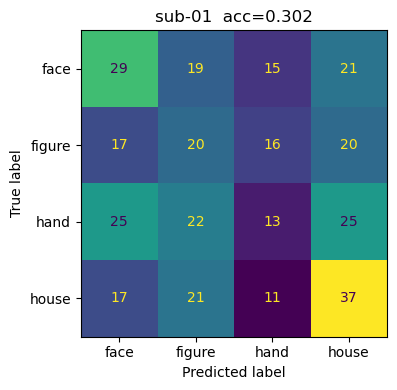

In [10]:
from nilearn.maskers import NiftiMasker

# Apply brain mask to get (n_trials, n_voxels) matrix
mask_path = sub.brain_mask['learning1']
masker = NiftiMasker(mask_img=mask_path, standardize=False).fit()
X = masker.transform(betas_img)     # (n_stim_trials, n_voxels)

y      = trial_info['stim_cat'].values
groups = trial_info['run'].values

print(f"X shape: {X.shape}")
print(f"Classes: {sorted(set(y))}")
print(f"Trials per run: {pd.Series(groups).value_counts().sort_index().to_dict()}")
print()

# Leave-one-run-out cross-validated predictions
logo   = LeaveOneGroupOut()
y_pred = cross_val_predict(LinearSVC(max_iter=5000), X, y, cv=logo, groups=groups)
acc    = (y_pred == y).mean()

print(f"Category decoding accuracy: {acc:.3f}  (chance = 0.25)")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=ax, colorbar=False)
ax.set_title(f"sub-{SUBJECT}  acc={acc:.3f}")
plt.tight_layout()
plt.show()


## Step 9b — Category decoding: visual cortex only

Whole-brain decoding (30.2%) is expected to be low — 65,617 voxels, most carrying no category information. Restricting to visual cortex (Harvard-Oxford atlas: occipital + fusiform + inferior temporal regions) leaves 7,570 voxels (~8.7× reduction) and targets the regions where face/house/hand/figure responses are well-established. Should run in seconds.

Regions included:
  Lateral Occipital Cortex, superior division
  Lateral Occipital Cortex, inferior division
  Intracalcarine Cortex
  Cuneal Cortex
  Lingual Gyrus
  Temporal Fusiform Cortex, anterior division
  Temporal Fusiform Cortex, posterior division
  Temporal Occipital Fusiform Cortex
  Occipital Fusiform Gyrus
  Occipital Pole

Visual cortex: 7,570 voxels  (whole-brain: 65,617,  reduction: 8.7×)

Category decoding accuracy:
  Visual cortex : 0.466
  Whole brain   : 0.302
  Chance        : 0.250


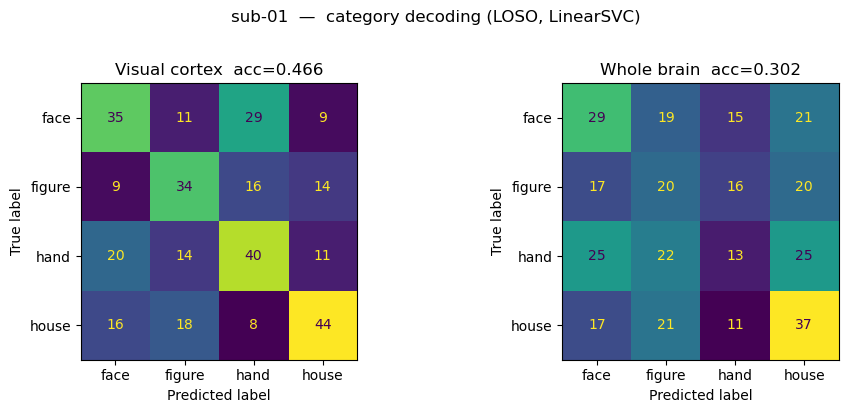

In [11]:
from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.image import resample_to_img, math_img

# --- Build visual cortex mask from Harvard-Oxford cortical atlas ---
atlas = fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_data = atlas.maps.get_fdata()

visual_keywords = ['Occipital', 'Lingual', 'Cuneal', 'Intracalcarine',
                   'Fusiform', 'Temporal Occipital']

vis_data = np.zeros(atlas_data.shape, dtype=np.uint8)
print("Regions included:")
for i, label in enumerate(atlas.labels):
    if any(k in label for k in visual_keywords):
        vis_data[atlas_data == i] = 1
        print(f"  {label}")

vis_mask_mni  = image.new_img_like(atlas.maps, vis_data)
vis_mask_func = resample_to_img(vis_mask_mni, ref_img, interpolation='nearest')
brain_mask_func = resample_to_img(nib.load(mask_path), ref_img, interpolation='nearest')
vis_mask = math_img('(v > 0) & (b > 0)', v=vis_mask_func, b=brain_mask_func)

n_vis  = int(vis_mask.get_fdata().sum())
n_full = X.shape[1]
print(f"\nVisual cortex: {n_vis:,} voxels  (whole-brain: {n_full:,},  reduction: {n_full/n_vis:.1f}×)")

# --- Decode ---
vis_masker = NiftiMasker(mask_img=vis_mask, standardize=False).fit()
X_vis = vis_masker.transform(betas_img)

y_pred_vis = cross_val_predict(LinearSVC(max_iter=5000), X_vis, y, cv=LeaveOneGroupOut(), groups=groups)
acc_vis = (y_pred_vis == y).mean()

print(f"\nCategory decoding accuracy:")
print(f"  Visual cortex : {acc_vis:.3f}")
print(f"  Whole brain   : {acc:.3f}")
print(f"  Chance        : 0.250")

# --- Side-by-side confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y, y_pred_vis, ax=axes[0], colorbar=False)
axes[0].set_title(f"Visual cortex  acc={acc_vis:.3f}")
ConfusionMatrixDisplay.from_predictions(y, y_pred, ax=axes[1], colorbar=False)
axes[1].set_title(f"Whole brain  acc={acc:.3f}")
plt.suptitle(f"sub-{SUBJECT}  —  category decoding (LOSO, LinearSVC)", y=1.02)
plt.tight_layout()
plt.show()